In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
import ast
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

In [4]:
cell_history_df1 = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/script/12052026_exhaustion.csv.gz", compression="gzip")
cell_history_df2 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\18052026_exhaustion.csv.gz", compression='gzip')
cell_history_df3 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\01062026_exhaustion.csv.gz", compression='gzip')
cell_history_df4 = pd.read_csv("C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\02062026_exhaustion.csv.gz", compression='gzip')
# Cell 0 — after loading
cell_history_df1["run_id"] = 0
cell_history_df2["run_id"] = 1
cell_history_df3["run_id"] = 2
cell_history_df4["run_id"] = 3

# Cell 1 — concat stays the same
df = pd.concat([cell_history_df1, cell_history_df2, cell_history_df3, cell_history_df4], ignore_index=True)

In [5]:
def parse_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    return ast.literal_eval(x)

df["contacts"] = df["contacts"].apply(parse_list)

if "killed_by" in df.columns:
    df["killed_by"] = df["killed_by"].apply(parse_list)

In [ ]:
killers = df[df["cell_type"] == "killer"].sort_values(["run_id", "cell_id", "step"])
targets = df[df["cell_type"] == "target"]

N_KILLER_PER_RUN = killers["cell_id"].max() + 1


N_KILLER = N_KILLER_PER_RUN * df["run_id"].nunique()

sequences = [[] for _ in range(N_KILLER)]

prev_contacts = [set() for _ in range(N_KILLER)]

kill_map = {}

for _, row in targets.iterrows():
    if row["killed_by"]:
        run_id = row["run_id"]
        t = (run_id, row["cell_id"])

        for k_local in row["killed_by"]:
            k_global = run_id * N_KILLER_PER_RUN + k_local
            kill_map.setdefault(t, set()).add(k_global)


for _, row in killers.iterrows():

    run_id = row["run_id"]

    k = run_id * N_KILLER_PER_RUN + row["cell_id"]

    contacts = {(run_id, t) for t in row["contacts"]}

    new_targets = contacts - prev_contacts[k]

    for t in new_targets:
        lethal = 1 if k in kill_map.get(t, set()) else 0
        sequences[k].append(lethal)

    prev_contacts[k] = contacts

In [7]:
def _hdi(x, prob=0.95):
    """
    Approximate highest-density interval for 1D samples.
    Returns (lower, upper).
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return (np.nan, np.nan)
    if x.size == 1:
        return (x[0], x[0])

    x = np.sort(x)
    n = x.size
    interval = int(np.floor(prob * n))

    if interval < 1:
        return (x[0], x[-1])
    if interval >= n:
        return (x[0], x[-1])

    widths = x[interval:] - x[:n - interval]
    i = np.argmin(widths)
    return (x[i], x[i + interval])

In [8]:
def parse_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    return ast.literal_eval(x)

df["contacts"] = df["contacts"].apply(parse_list)

if "killed_by" in df.columns:
    df["killed_by"] = df["killed_by"].apply(parse_list)

C:\Users\szonj\AppData\Local\Temp\ipykernel_43020\2990880463.py:2: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if pd.isna(x):


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [10]:
killers = df[df["cell_type"] == "killer"].sort_values(["cell_id","step"])
targets = df[df["cell_type"] == "target"]

N_KILLER = killers["cell_id"].max() + 1
sequences = [[] for _ in range(N_KILLER)]

prev_contacts = [set() for _ in range(N_KILLER)]

# map target -> killers that killed it
kill_map = {}
for _,row in targets.iterrows():
    if row["killed_by"]:
        t = row["cell_id"]
        kill_map.setdefault(t,set()).update(row["killed_by"])


for _,row in killers.iterrows():

    k = row["cell_id"]
    contacts = set(row["contacts"])

    new_targets = contacts - prev_contacts[k]

    for t in new_targets:
        lethal = 1 if k in kill_map.get(t,set()) else 0
        sequences[k].append(lethal)

    prev_contacts[k] = contacts

KeyboardInterrupt: 

In [14]:
def heatmap_contacts_vs_kills(
    out,
    *,
    use_total_contacts: bool = True,
    color=None,
    match_heatmap_to_marginals: bool = False,
    mode: str = "frequency",
    bins_x: int | None = None,
    bins_y: int | None = None,
    x_max: int | None = None,
    y_max: int | None = None,
    square_range: bool = True,
    figsize=(9.2, 7.6),
    dpi=300,
    cmap="YlGnBu",
    cmap_min: float = 0.3,
    cmap_max: float = 0.9,
    density: bool = False,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str = "Kills per killer cell",
    show_hdi_mean: bool = True,
    zero_color: str = "0.9",
    cbar_label_inside: bool = True,
    cbar_label: str | None = None,
    save_png=False,
    png_path="contacts_vs_kills_heatmap.png",
    save_pdf=False,
    pdf_path="contacts_vs_kills_heatmap.pdf",
):
    # ------------------------------------------------------------------
    # Accept either:
    # 1) old format: out = {"x": nonlethal_contacts, "y": kills}
    # 2) new format: out = sequences, where each NK has [0, 1, 0, 1, ...]
    # ------------------------------------------------------------------
    if isinstance(out, dict):
        x_nonlethal = np.asarray(out["x"], dtype=float)
        y_kills = np.asarray(out["y"], dtype=float)

    else:
        sequences = out

        y_kills = np.asarray(
            [np.sum(seq) for seq in sequences],
            dtype=float
        )

        x_nonlethal = np.asarray(
            [len(seq) - np.sum(seq) for seq in sequences],
            dtype=float
        )

    if use_total_contacts:
        x_contacts = x_nonlethal + y_kills
        if xlabel is None:
            xlabel = "Contacts per killer cell"
    else:
        x_contacts = x_nonlethal
        if xlabel is None:
            xlabel = "Non-lethal contacts per killer cell"

    if x_contacts.size == 0:
        raise ValueError(
            "Empty x/y data: input must contain per-killer contact sequences or out['x']/out['y']"
        )

    x_int = np.asarray(np.round(x_contacts), dtype=int)
    y_int = np.asarray(np.round(y_kills), dtype=int)

    if x_max is None:
        x_max = int(np.max(x_int))
    if y_max is None:
        y_max = int(np.max(y_int))

    x_max = max(0, int(x_max))
    y_max = max(0, int(y_max))

    # Range
    if square_range:
        m = max(x_max, y_max)
        x_max = m
        y_max = m

    if bins_x is None:
        bins_x = x_max + 1
    if bins_y is None:
        bins_y = y_max + 1

    bins_x = int(max(1, bins_x))
    bins_y = int(max(1, bins_y))

    x_edges = np.linspace(-0.5, x_max + 0.5, bins_x + 1)
    y_edges = np.linspace(-0.5, y_max + 0.5, bins_y + 1)

    mode = str(mode).strip().lower()

    if density and mode != "count":
        raise ValueError("Use either density=True or mode in {'count','frequency'}, not both")

    if mode not in {"count", "frequency"}:
        raise ValueError("mode must be 'count' or 'frequency'")

    H, xedges, yedges = np.histogram2d(
        x_int,
        y_int,
        bins=[x_edges, y_edges],
        density=density
    )

    H = H.T  # (y, x) for imshow

    if mode == "frequency":
        total = float(np.sum(H))
        if total > 0:
            H = H / total

    # Heatmap
    positives = H[H > 0]

    if positives.size:
        vmin = float(np.min(positives))
        vmax = float(np.max(H))
        if vmax <= 0:
            vmax = vmin
    else:
        vmin = 0.0
        vmax = 1.0

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=False)
    H_plot = np.ma.masked_where(H == 0, H)

    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Layout
    gs = gridspec.GridSpec(
        2,
        4,
        width_ratios=[0.22, 0.38, 4.0, 1.4],
        height_ratios=[1.4, 4.0],
        wspace=0.08,
        hspace=0.08,
    )

    ax_cbar = fig.add_subplot(gs[1, 0])
    ax_gap = fig.add_subplot(gs[1, 1])
    ax_gap.axis("off")

    ax_top = fig.add_subplot(gs[0, 2])
    ax_main = fig.add_subplot(gs[1, 2])
    ax_right = fig.add_subplot(gs[1, 3])

    ax_cbar_top = fig.add_subplot(gs[0, 0])
    ax_cbar_top.axis("off")

    ax_gap_top = fig.add_subplot(gs[0, 1])
    ax_gap_top.axis("off")

    ax_corner = fig.add_subplot(gs[0, 3])
    ax_corner.axis("off")

    # Colormap
    cmap_min = float(cmap_min)
    cmap_max = float(cmap_max)

    if not (0.0 <= cmap_min <= 1.0 and 0.0 <= cmap_max <= 1.0 and cmap_min <= cmap_max):
        raise ValueError("cmap_min/cmap_max must satisfy 0<=cmap_min<=cmap_max<=1")

    def _make_sequential_from_color(c):
        r, g, b, a = mcolors.to_rgba(c)

        # Light background tint -> full color
        light = (
            0.92 + 0.08 * r,
            0.92 + 0.08 * g,
            0.92 + 0.08 * b,
            1.0
        )

        dark = (r, g, b, 1.0)

        return mcolors.LinearSegmentedColormap.from_list(
            "marginal_seq",
            [light, dark]
        )

    if match_heatmap_to_marginals and (color is not None):
        base_cmap = _make_sequential_from_color(color)
    else:
        base_cmap = plt.get_cmap(cmap)

    if (cmap_min, cmap_max) != (0.0, 1.0):
        xs = np.linspace(cmap_min, cmap_max, 256)

        cmap_obj = mcolors.LinearSegmentedColormap.from_list(
            f"{base_cmap.name}_trunc_{cmap_min:.2f}_{cmap_max:.2f}",
            base_cmap(xs),
        )
    else:
        cmap_obj = base_cmap

    try:
        cmap_obj = cmap_obj.copy()
    except Exception:
        pass

    try:
        cmap_obj.set_bad(color=(0, 0, 0, 0))
        cmap_obj.set_under(color=(0, 0, 0, 0))
    except Exception:
        pass

    im = ax_main.imshow(
        H_plot,
        origin="lower",
        aspect="auto",
        cmap=cmap_obj,
        norm=norm,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        interpolation="nearest",
    )

    # Colorbar
    cbar = fig.colorbar(im, cax=ax_cbar)

    try:
        cbar.ax.yaxis.set_label_position("left")
        cbar.ax.yaxis.set_ticks_position("left")
    except Exception:
        pass

    if cbar_label is None:
        if density:
            cbar_label = "Density"
        else:
            cbar_label = "Frequency" if mode == "frequency" else "Count"

    if cbar_label_inside:
        cbar.set_label("")
        cbar.ax.text(
            0.5,
            0.5,
            str(cbar_label),
            transform=cbar.ax.transAxes,
            ha="center",
            va="center",
            rotation=90,
            fontsize=10,
            color="white",
            bbox=dict(
                facecolor="none",
                edgecolor="none",
                alpha=0.0,
                pad=2.0
            ),
        )
    else:
        cbar.set_label(str(cbar_label))

    ax_main.set_xlabel(xlabel)
    ax_main.set_ylabel(ylabel)

    # Axes
    ax_main.set_xticks(np.arange(0, int(x_max) + 1, 1))
    ax_main.set_yticks(np.arange(0, int(y_max) + 1, 1))
    ax_main.grid(True, alpha=0.15, linestyle="--")

    if title:
        ax_top.set_title(title)

    # Marginals
    marginal_color = color if color is not None else "0.2"

    if density:
        marginal_kind_label = "Density"
        marginal_hist_kwargs = dict(density=True)

    elif mode == "frequency":
        marginal_kind_label = "Frequency"

        w = np.ones_like(x_int, dtype=float)
        w = w / float(np.sum(w))

        marginal_hist_kwargs = dict(
            weights=w,
            density=False
        )

    else:
        marginal_kind_label = "Count"
        marginal_hist_kwargs = dict(density=False)

    ax_top.hist(
        x_int,
        bins=x_edges,
        color=marginal_color,
        alpha=0.35,
        edgecolor="none",
        linewidth=0,
        **marginal_hist_kwargs,
    )

    ax_right.hist(
        y_int,
        bins=y_edges,
        orientation="horizontal",
        color=marginal_color,
        alpha=0.35,
        edgecolor="none",
        linewidth=0,
        **marginal_hist_kwargs,
    )

    # Alignment
    xlim0 = (-0.5, float(x_max) + 0.5)
    ylim0 = (-0.5, float(y_max) + 0.5)

    ax_main.set_xlim(*xlim0)
    ax_main.set_ylim(*ylim0)

    ax_main.set_aspect("equal", adjustable="datalim")

    try:
        ax_main.apply_aspect()
    except Exception:
        pass

    xlim = ax_main.get_xlim()
    ylim = ax_main.get_ylim()

    ax_top.set_xlim(*xlim)
    ax_right.set_ylim(*ylim)

    ax_top.margins(x=0)
    ax_right.margins(y=0)

    if show_hdi_mean:
        stat_color = cmap_obj(0.85)

        mx = float(np.mean(x_int))
        my = float(np.mean(y_int))

        lx, ux = _hdi(x_int, 0.95)
        ly, uy = _hdi(y_int, 0.95)

        ax_top.axvspan(lx, ux, color=stat_color, alpha=0.18)
        ax_top.axvline(mx, color=stat_color, lw=2)

        ax_right.axhspan(ly, uy, color=stat_color, alpha=0.18)
        ax_right.axhline(my, color=stat_color, lw=2)

        ax_top.text(
            0.99,
            0.95,
            f"mean={mx:.2f}\nHDI95%=[{lx:.0f},{ux:.0f}]",
            transform=ax_top.transAxes,
            ha="right",
            va="top",
            fontsize=10,
        )

        ax_right.text(
            0.05,
            0.99,
            f"mean={my:.2f}\nHDI95%=[{ly:.0f},{uy:.0f}]",
            transform=ax_right.transAxes,
            ha="left",
            va="top",
            rotation=0,
            fontsize=10,
        )

    # Styling
    plt.setp(ax_top.get_xticklabels(), visible=False)
    ax_top.set_ylabel(marginal_kind_label)
    ax_top.grid(True, alpha=0.15, linestyle="--")

    plt.setp(ax_right.get_yticklabels(), visible=False)
    ax_right.set_xlabel(marginal_kind_label)
    ax_right.grid(True, alpha=0.15, linestyle="--")

    # Save
    if save_png:
        plt.savefig(
            png_path,
            dpi=dpi,
            bbox_inches="tight",
            transparent=True
        )

    if save_pdf:
        plt.savefig(
            pdf_path,
            bbox_inches="tight",
            transparent=True
        )

    return {
        "x_mean": float(np.mean(x_int)),
        "x_hdi95": _hdi(x_int, 0.95),
        "y_mean": float(np.mean(y_int)),
        "y_hdi95": _hdi(y_int, 0.95),
        "x_max": int(x_max),
        "y_max": int(y_max),
    }

In [21]:
x_vals = []
y_vals = []

sequences1 = sequences.copy()
for seq in sequences1:
    seq = np.array(seq)

    nonlethal = np.sum(seq == 0)
    lethal = np.sum(seq == 1)

    x_vals.append(nonlethal)
    y_vals.append(lethal)

out = {
    "x": np.array(x_vals),
    "y": np.array(y_vals),
}

In [20]:
print(sequences)

[[1, 1, 1], [1, 1, 0, 1, 1, 1], [1, 1, 1, 0], [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1], [0, 1, 1, 0, 1, 1, 0, 1, 1], [1, 1, 0, 1, 0], [0], [1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1], [0, 1, 1, 1], [1, 1, 0, 0, 0], [1, 1, 1, 0, 0, 1, 0, 1, 1], [1, 1], [0, 0, 0, 0, 1, 0], [1, 1, 0, 1, 0, 1, 1, 1, 1], [1, 1, 0, 0], [1, 1, 0], [1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1], [1], [1, 0, 0, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 1, 1], [1, 1], [1, 1, 1], [1, 1], [0, 1, 1, 0], [0, 1, 0], [0, 0, 1, 1, 0, 0, 0], [0, 1, 1, 1, 1], [], [], [1, 1, 1, 1], [1, 0, 1], [], [1, 1, 1], [1, 1, 1, 0, 0, 1, 1, 1, 0], [1, 0], [1, 1, 1, 1, 1, 1, 0, 0], [0, 1, 1, 1], [1], [1, 1], [0, 1, 0], [1, 1, 1, 1, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 1, 0, 1], [1, 0, 1, 1], [0, 0, 0, 0], [1, 0, 0], [0, 1, 0, 1, 1], [1, 0, 1], [1, 0], [1, 1, 1, 1, 0], [0, 0, 1, 1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 0], [1, 1], [0, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0], [1, 1, 1, 0

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


{'x_mean': 4.42, 'x_hdi95': (np.float64(0.0), np.float64(9.0)), 'y_mean': 2.6675, 'y_hdi95': (np.float64(0.0), np.float64(6.0)), 'x_max': 16, 'y_max': 16}


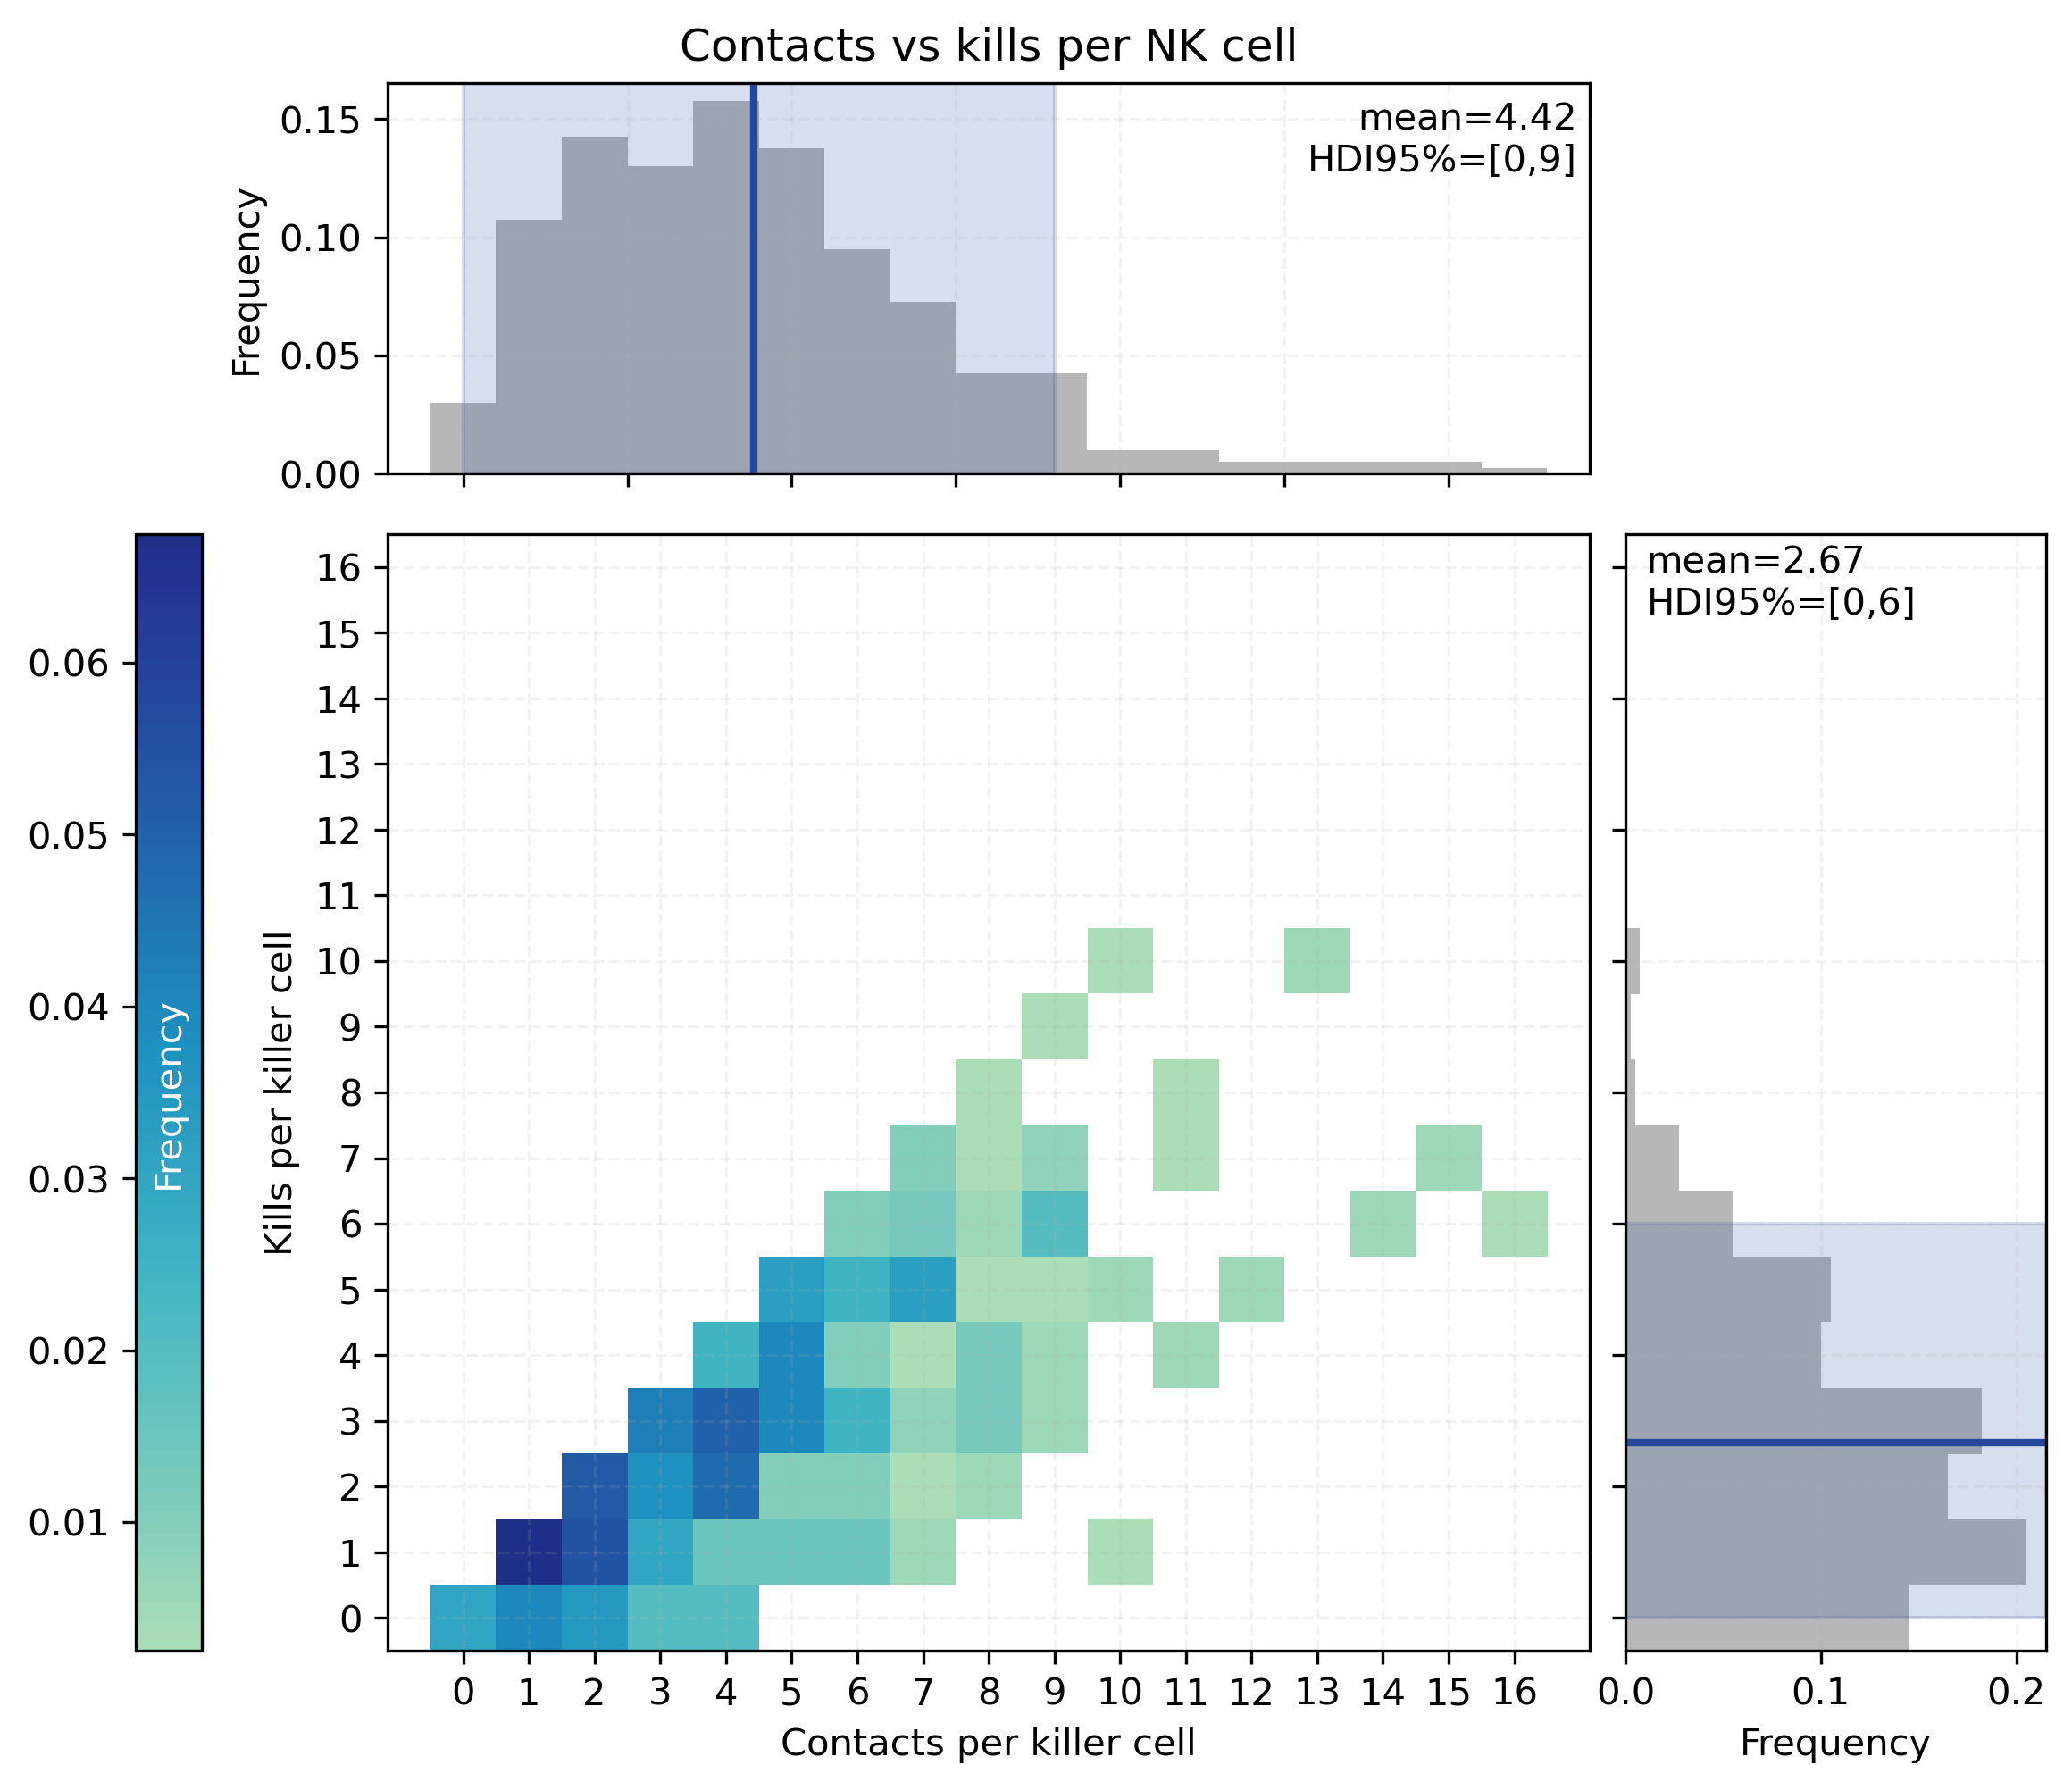

In [22]:

stats = heatmap_contacts_vs_kills(
    sequences,
    use_total_contacts=True,
    title="Contacts vs kills per NK cell"
)

print(stats)